# Loading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

patients = pd.read_csv(r"C:\Users\AFAQE\Desktop\Healthcare\patient_admissions.csv")
bed_occupancy = pd.read_csv(r"C:\Users\AFAQE\Desktop\Healthcare\bed_occupancy.csv")
staff_workload = pd.read_csv(r"C:\Users\AFAQE\Desktop\Healthcare\staff_workload.csv")
 
print(f"Patient Admissions: {len(patients):,} rows")
print(f"Bed Occupancy: {len(bed_occupancy):,} rows")
print(f"Staff Workload: {len(staff_workload):,} rows")


Patient Admissions: 500,000 rows
Bed Occupancy: 3,655 rows
Staff Workload: 3,655 rows


# The First KPI
## KPI 1 : Bed Occupancy Rate by Department

In [3]:
occupancy_by_dept = (bed_occupancy.groupby("Department")["Occupancy_Rate"]
                      .mean().mul(100).round(2).sort_values(ascending=False))
print("\n=== KPI 1: Avg Bed Occupancy Rate by Department ===")
print(occupancy_by_dept)



=== KPI 1: Avg Bed Occupancy Rate by Department ===
Department
ICU                 91.13
Surgery             82.10
General Medicine    79.99
Emergency           78.09
Pediatrics          74.26
Name: Occupancy_Rate, dtype: float64


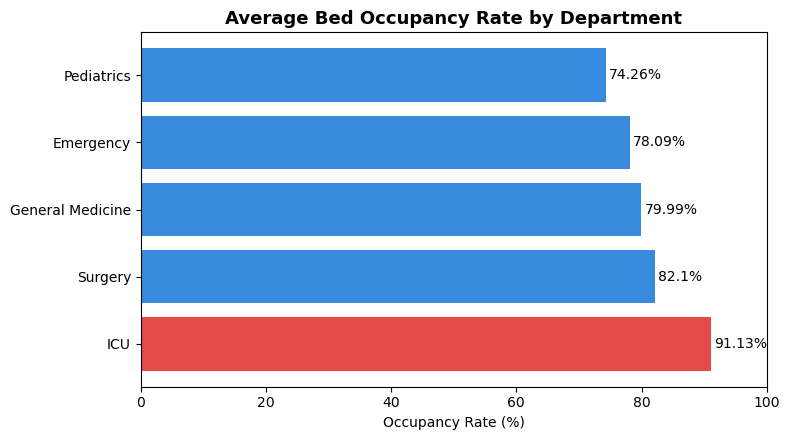

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#E24B4A' if v > 85 else '#378ADD' for v in occupancy_by_dept.values]
bars = ax.barh(occupancy_by_dept.index, occupancy_by_dept.values, color=colors)
ax.set_xlabel('Occupancy Rate (%)')
ax.set_title('Average Bed Occupancy Rate by Department', fontsize=13, fontweight='bold')
for bar, val in zip(bars, occupancy_by_dept.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(r"C:\Users\AFAQE\Desktop\Healthcare\Healthcare.png", dpi=150, bbox_inches='tight')
plt.show()

# The Second KPI
## KPI 2 : Staff Workload — Patient-to-Nurse Ratio

In [13]:
workload_by_dept = (staff_workload.groupby("Department")["Patient_To_Nurse_Ratio"]
                     .mean().round(2).sort_values(ascending=False))
print("\n=== KPI 2: Avg Patient-to-Nurse Ratio by Department ===")
print(workload_by_dept)


=== KPI 2: Avg Patient-to-Nurse Ratio by Department ===
Department
General Medicine    6.00
Pediatrics          5.04
Emergency           3.99
Surgery             3.00
ICU                 2.00
Name: Patient_To_Nurse_Ratio, dtype: float64


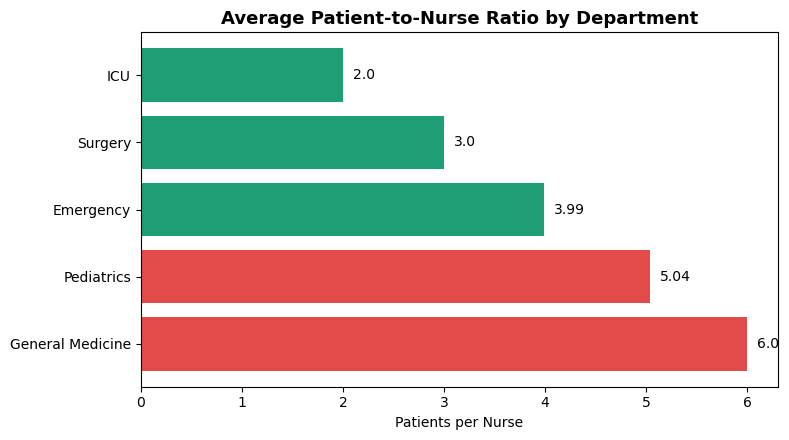

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors2 = ['#E24B4A' if v > 5 else '#1D9E75' for v in workload_by_dept.values]
bars2 = ax.barh(workload_by_dept.index, workload_by_dept.values, color=colors2)
ax.set_xlabel('Patients per Nurse')
ax.set_title('Average Patient-to-Nurse Ratio by Department', fontsize=13, fontweight='bold')
for bar, val in zip(bars2, workload_by_dept.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(r"C:\Users\AFAQE\Desktop\Healthcare\Healthcare.png", dpi=150, bbox_inches='tight')
plt.show()


# The Third KPI 
## KPI 3 : Treatment Timeline Efficiency

In [18]:
inefficiency_pct = ((patients['Length_Of_Stay_Days'].sum() - patients['Ideal_Stay_Days'].sum())
                     / patients['Ideal_Stay_Days'].sum()) * 100
delay_rate = patients['Discharge_Delayed'].mean() * 100
print(f"\n=== KPI 3: Treatment Timeline Efficiency ===")
print(f"Overall length-of-stay inefficiency: {inefficiency_pct:.2f}%")
print(f"Discharge delay rate: {delay_rate:.2f}%")
 
stay_by_dept = patients.groupby("Department").agg(
    Avg_Actual_Stay=("Length_Of_Stay_Days", "mean"),
    Avg_Ideal_Stay=("Ideal_Stay_Days", "mean")
).round(2)
stay_by_dept["Inefficiency_Pct"] = (
    (stay_by_dept["Avg_Actual_Stay"] - stay_by_dept["Avg_Ideal_Stay"])
    / stay_by_dept["Avg_Ideal_Stay"] * 100
).round(2)
print(stay_by_dept.sort_values("Inefficiency_Pct", ascending=False))



=== KPI 3: Treatment Timeline Efficiency ===
Overall length-of-stay inefficiency: 17.01%
Discharge delay rate: 37.89%
                  Avg_Actual_Stay  Avg_Ideal_Stay  Inefficiency_Pct
Department                                                         
Emergency                    1.77            1.51             17.22
ICU                          6.08            5.19             17.15
Surgery                      3.63            3.10             17.10
Pediatrics                   2.81            2.40             17.08
General Medicine             4.46            3.81             17.06


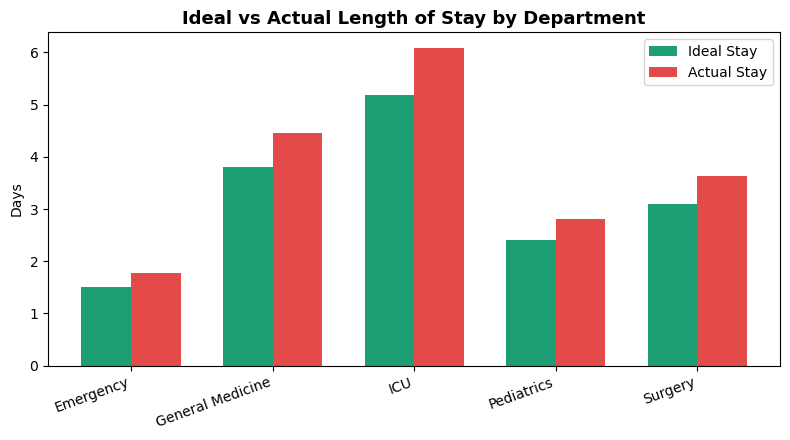

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(stay_by_dept))
width = 0.35
ax.bar(x - width/2, stay_by_dept["Avg_Ideal_Stay"], width, label='Ideal Stay', color='#1D9E75')
ax.bar(x + width/2, stay_by_dept["Avg_Actual_Stay"], width, label='Actual Stay', color='#E24B4A')
ax.set_xticks(x)
ax.set_xticklabels(stay_by_dept.index, rotation=20, ha='right')
ax.set_ylabel('Days')
ax.set_title('Ideal vs Actual Length of Stay by Department', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\AFAQE\Desktop\Healthcare", dpi=150, bbox_inches='tight')
plt.show()


# The Fourth KPI
## KPI 4: Patient Fall Incidents by Department

In [24]:
fall_rate_by_dept = (patients.groupby("Department")["Had_Fall_Incident"]
                      .mean().mul(100).round(2).sort_values(ascending=False))
overall_fall_rate = patients["Had_Fall_Incident"].mean() * 100
print(f"\n=== KPI 4: Patient Fall Incidents ===")
print(f"Overall fall rate: {overall_fall_rate:.2f}%")
print(fall_rate_by_dept)
 
# Fall rate by age group (high-risk monitoring)
patients['Age_Group'] = pd.cut(patients['Age'], bins=[0, 18, 40, 65, 100],
                                 labels=['0-18', '19-40', '41-65', '65+'])
fall_by_age = (patients.groupby('Age_Group')['Had_Fall_Incident']
               .mean().mul(100).round(2))
print("\nFall rate by age group:")
print(fall_by_age)



=== KPI 4: Patient Fall Incidents ===
Overall fall rate: 2.05%
Department
ICU                 3.51
Emergency           2.51
General Medicine    1.97
Surgery             1.64
Pediatrics          0.66
Name: Had_Fall_Incident, dtype: float64

Fall rate by age group:
Age_Group
0-18     1.16
19-40    1.79
41-65    1.83
65+      3.53
Name: Had_Fall_Incident, dtype: float64


C:\Users\AFAQE\AppData\Local\Temp\ipykernel_7372\13153862.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fall_by_age = (patients.groupby('Age_Group')['Had_Fall_Incident']


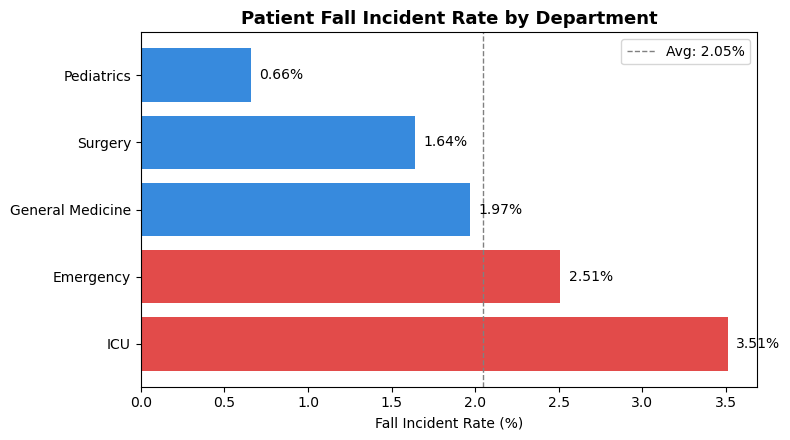

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors3 = ['#E24B4A' if v > overall_fall_rate else '#378ADD' for v in fall_rate_by_dept.values]
bars3 = ax.barh(fall_rate_by_dept.index, fall_rate_by_dept.values, color=colors3)
ax.axvline(overall_fall_rate, color='gray', linestyle='--', linewidth=1, label=f'Avg: {overall_fall_rate:.2f}%')
ax.set_xlabel('Fall Incident Rate (%)')
ax.set_title('Patient Fall Incident Rate by Department', fontsize=13, fontweight='bold')
for bar, val in zip(bars3, fall_rate_by_dept.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\AFAQE\Desktop\Healthcare", dpi=150, bbox_inches='tight')
plt.show()
